# 03 - EDA Segmentation client

Objectif : analyser `data/raw/data_cluster.csv` pour comprendre les profils clients, préparer les variables de clustering et identifier des segments actionnables.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../data/raw/data_cluster.csv"

In [2]:
df = pd.read_csv(DATA_PATH, sep=";")
print("Shape:", df.shape)
df.head()

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
print("Infos generales")
print(df.info())

missing = df.isna().sum().sort_values(ascending=False)
print("\nTop variables avec valeurs manquantes")
display(missing.head(10))

print("\nDoublons:", df.duplicated().sum())

const_cols = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
print("Colonnes constantes:", const_cols)

Infos generales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2

Income               24
ID                    0
NumDealsPurchases     0
Z_Revenue             0
Z_CostContact         0
Complain              0
AcceptedCmp2          0
AcceptedCmp1          0
AcceptedCmp5          0
AcceptedCmp4          0
dtype: int64


Doublons: 0
Colonnes constantes: ['Z_CostContact', 'Z_Revenue']


In [4]:
# Variables derivees de base
work = df.copy()
work["Dt_Customer"] = pd.to_datetime(work["Dt_Customer"], format="%d/%m/%Y", errors="coerce")
work["Income"] = work["Income"].fillna(work["Income"].median())
work["Age"] = 2026 - work["Year_Birth"]
work["Customer_Tenure_days"] = (pd.Timestamp("today").normalize() - work["Dt_Customer"]).dt.days
work["Children"] = work["Kidhome"] + work["Teenhome"]

spending_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
]
work["Total_Spending"] = work[spending_cols].sum(axis=1)

purchase_cols = ["NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
work["Total_Purchases"] = work[purchase_cols].sum(axis=1)

work[["Age", "Income", "Total_Spending", "Total_Purchases", "Children"]].describe()

,Age,Income,Total_Spending,Total_Purchases,Children
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,57.194196,52237.975446,605.798214,14.862054,0.950446
std,11.984069,25037.955891,602.249288,7.677173,0.751803
min,30.000000,1730.000000,5.000000,0.000000,0.000000
25%,49.000000,35538.750000,68.750000,8.000000,0.000000
50%,56.000000,51381.500000,396.000000,15.000000,1.000000
75%,67.000000,68289.750000,1045.500000,21.000000,1.000000
max,133.000000,666666.000000,2525.000000,44.000000,3.000000


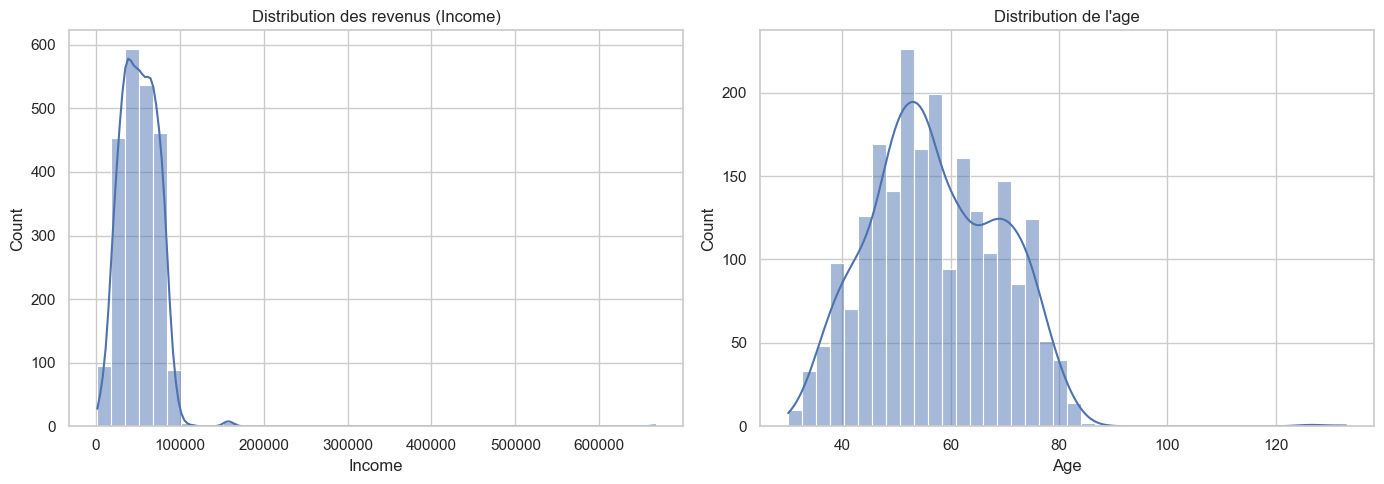

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(work["Income"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribution des revenus (Income)")
axes[0].set_xlabel("Income")

sns.histplot(work["Age"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Distribution de l'age")
axes[1].set_xlabel("Age")
plt.tight_layout()
plt.show()

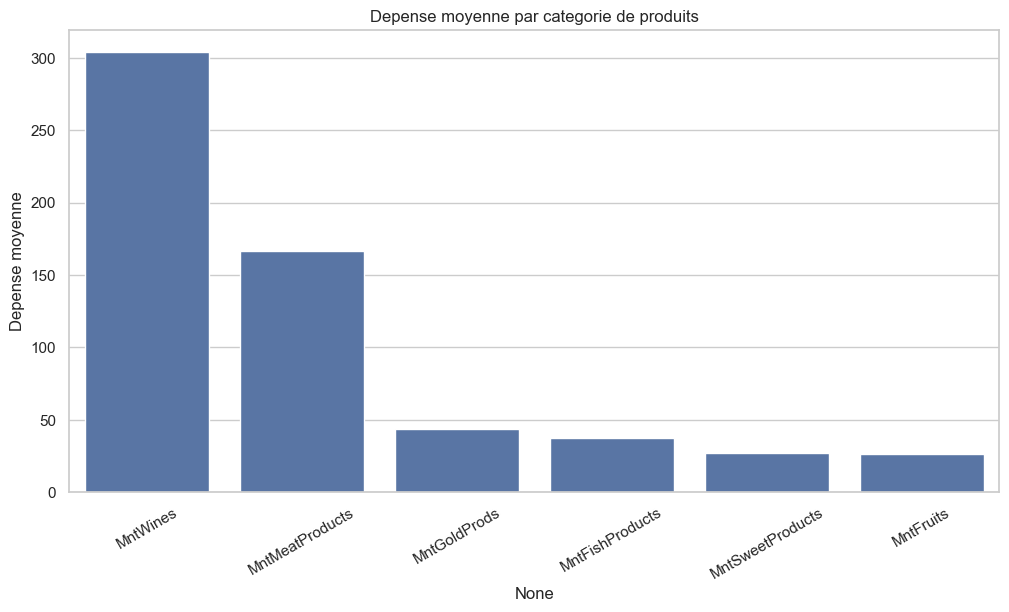

In [6]:
plt.figure(figsize=(12, 6))
spending_means = work[spending_cols].mean().sort_values(ascending=False)
sns.barplot(x=spending_means.index, y=spending_means.values)
plt.title("Depense moyenne par categorie de produits")
plt.ylabel("Depense moyenne")
plt.xticks(rotation=30)
plt.show()

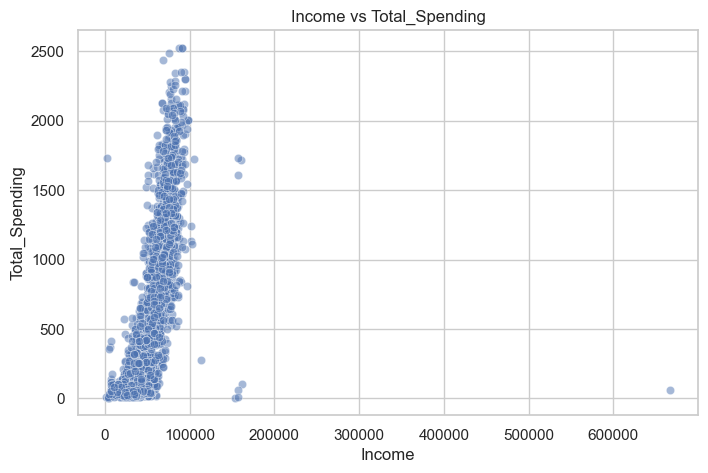

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=work, x="Income", y="Total_Spending", alpha=0.5)
plt.title("Income vs Total_Spending")
plt.xlabel("Income")
plt.ylabel("Total_Spending")
plt.show()

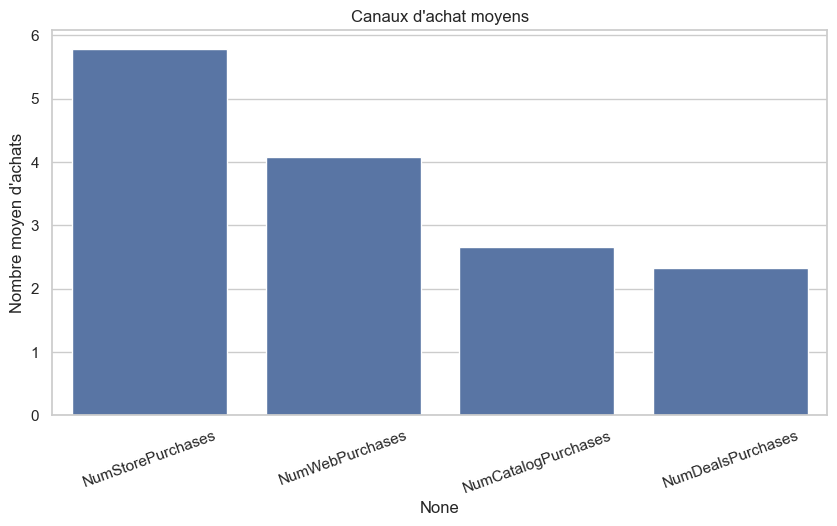

In [8]:
channel_cols = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumDealsPurchases"]
channel_means = work[channel_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=channel_means.index, y=channel_means.values)
plt.title("Canaux d'achat moyens")
plt.ylabel("Nombre moyen d'achats")
plt.xticks(rotation=20)
plt.show()

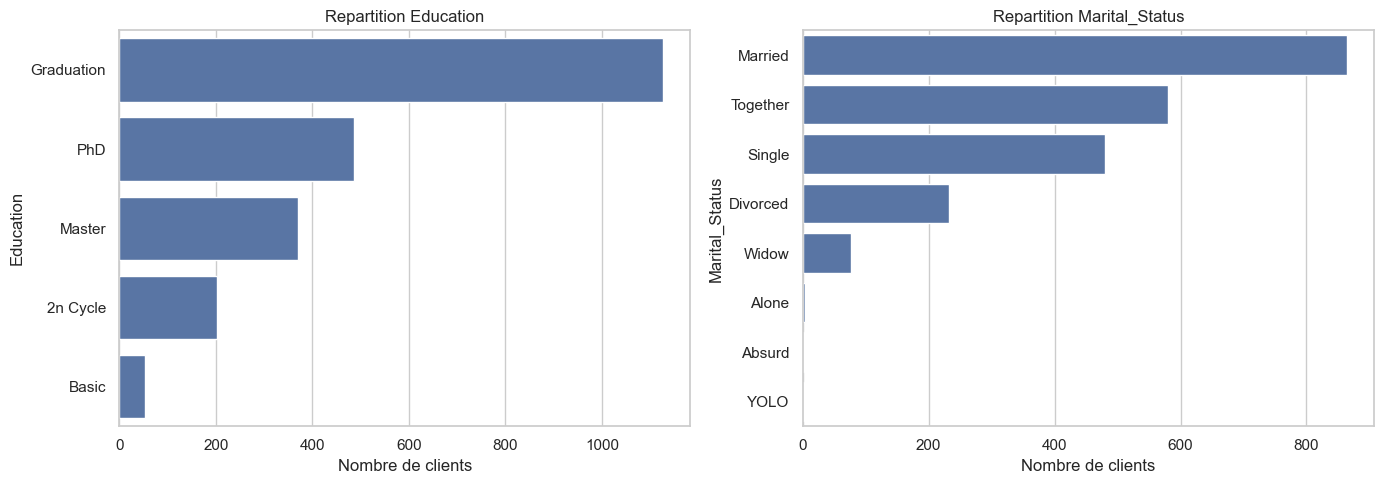

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edu_counts = work["Education"].value_counts().head(10)
sns.barplot(x=edu_counts.values, y=edu_counts.index, ax=axes[0])
axes[0].set_title("Repartition Education")
axes[0].set_xlabel("Nombre de clients")

marital_counts = work["Marital_Status"].value_counts().head(10)
sns.barplot(x=marital_counts.values, y=marital_counts.index, ax=axes[1])
axes[1].set_title("Repartition Marital_Status")
axes[1].set_xlabel("Nombre de clients")

plt.tight_layout()
plt.show()

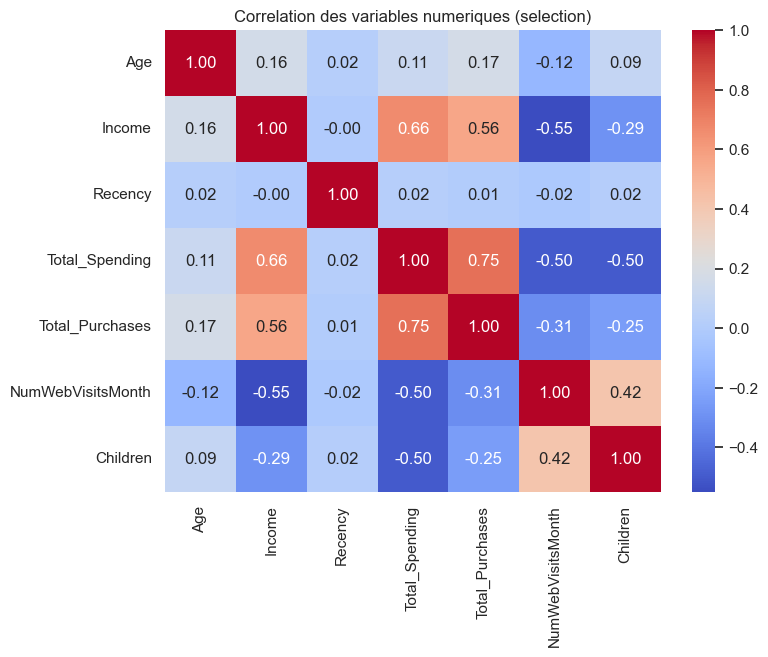

In [10]:
num_cols = [
    "Age",
    "Income",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumWebVisitsMonth",
    "Children",
]

corr = work[num_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation des variables numeriques (selection)")
plt.show()

Variance expliquee PC1+PC2: 0.5921114822876963


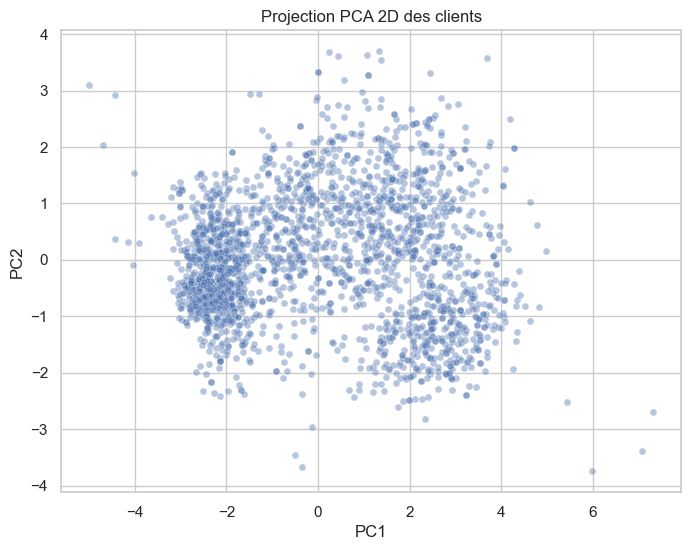

In [11]:
# Projection PCA 2D (exploratoire, avant clustering)
pca_features = [
    "Income",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Children",
    "Age",
]

X = work[pca_features].copy()
X = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X), columns=pca_features)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Variance expliquee PC1+PC2:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], alpha=0.4, s=25)
plt.title("Projection PCA 2D des clients")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Conclusion EDA segmentation

- `Income` contient des valeurs manquantes : imputation par médiane retenue.
- `Z_CostContact` et `Z_Revenue` sont constantes : exclues du clustering.
- `Total_Spending` et les canaux d'achat distinguent les comportements clients.
- `Recency` et `NumWebVisitsMonth` séparent clients engagés vs dormants.
- Quatre segments finaux retenus pour des actions marketing concrètes.

## Suite du projet

1. Notebook `04_modelisation_segmentation.ipynb` — comparaison des algorithmes et profils.
2. Script `src/models/train_clustering_model.py` — entraînement reproductible.
3. API `/predict/segment` et dashboard — attribution de segment en ligne.